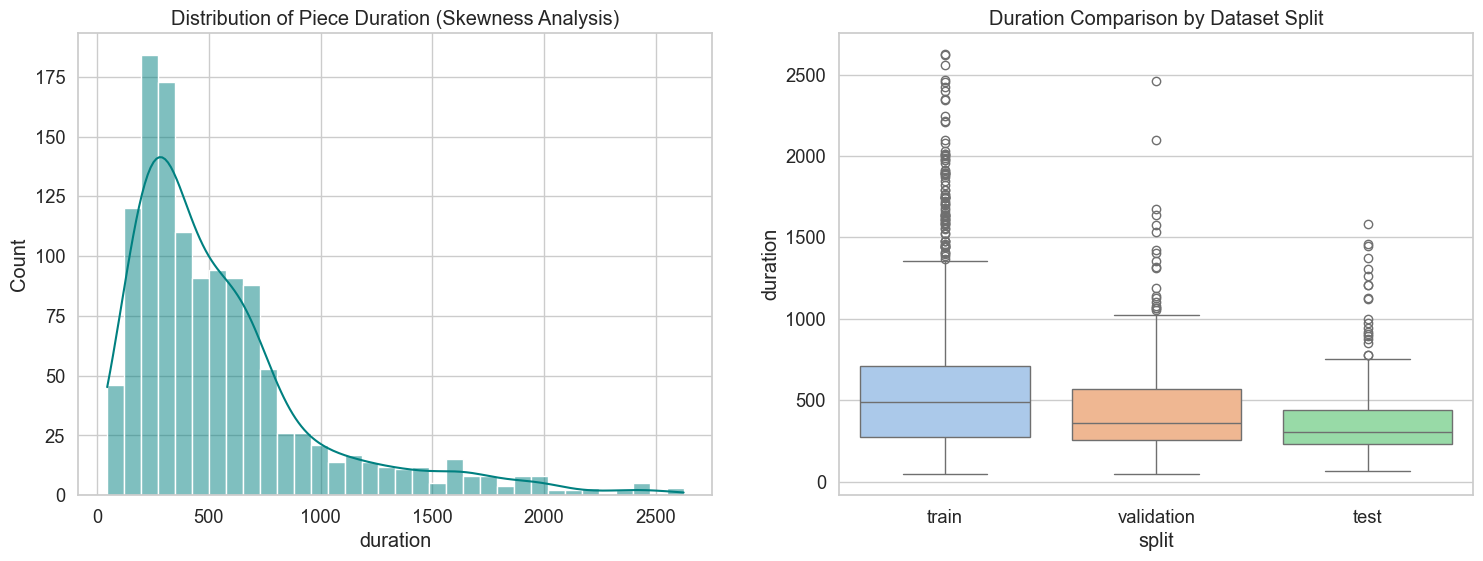

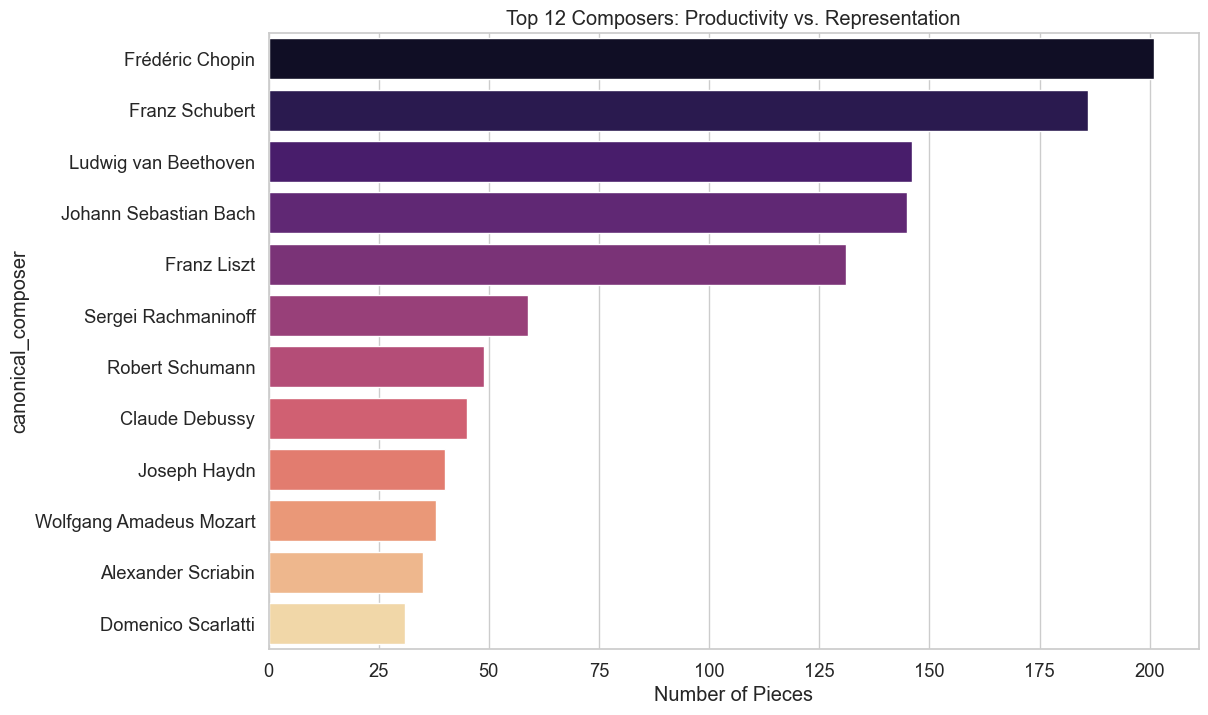

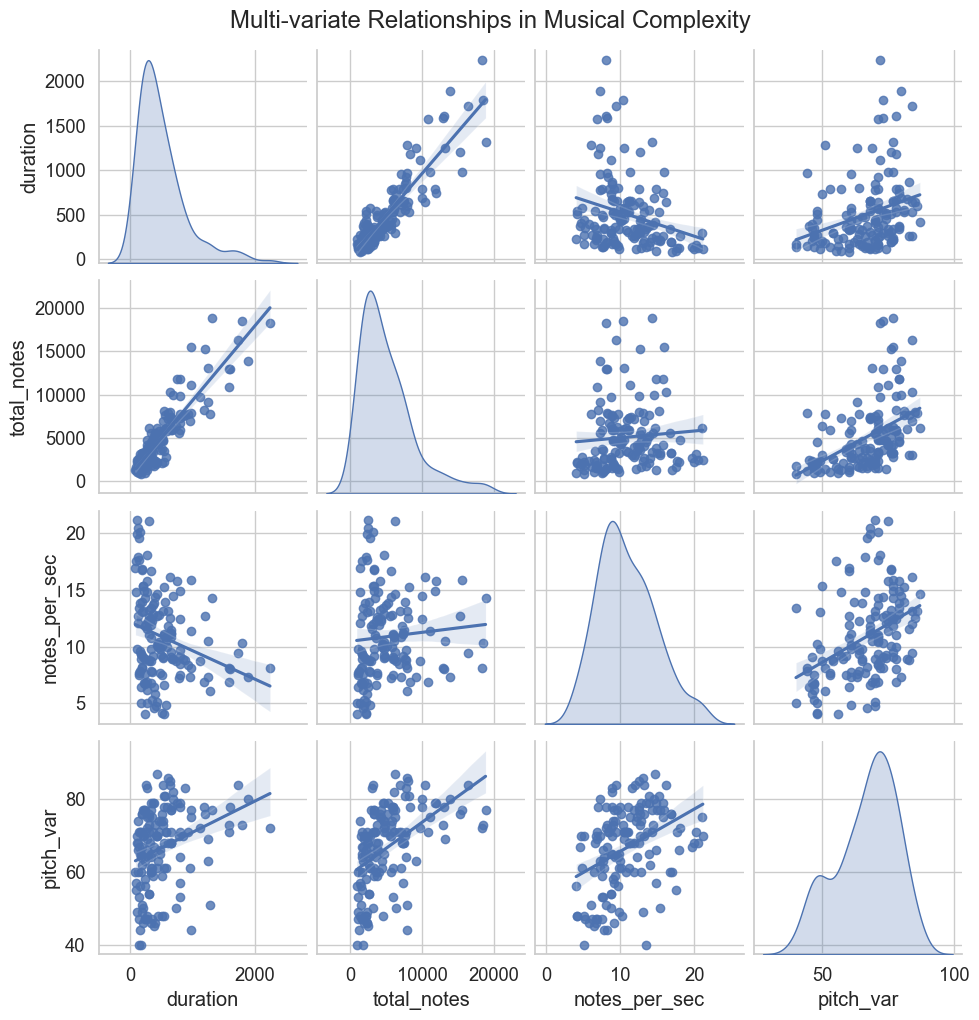

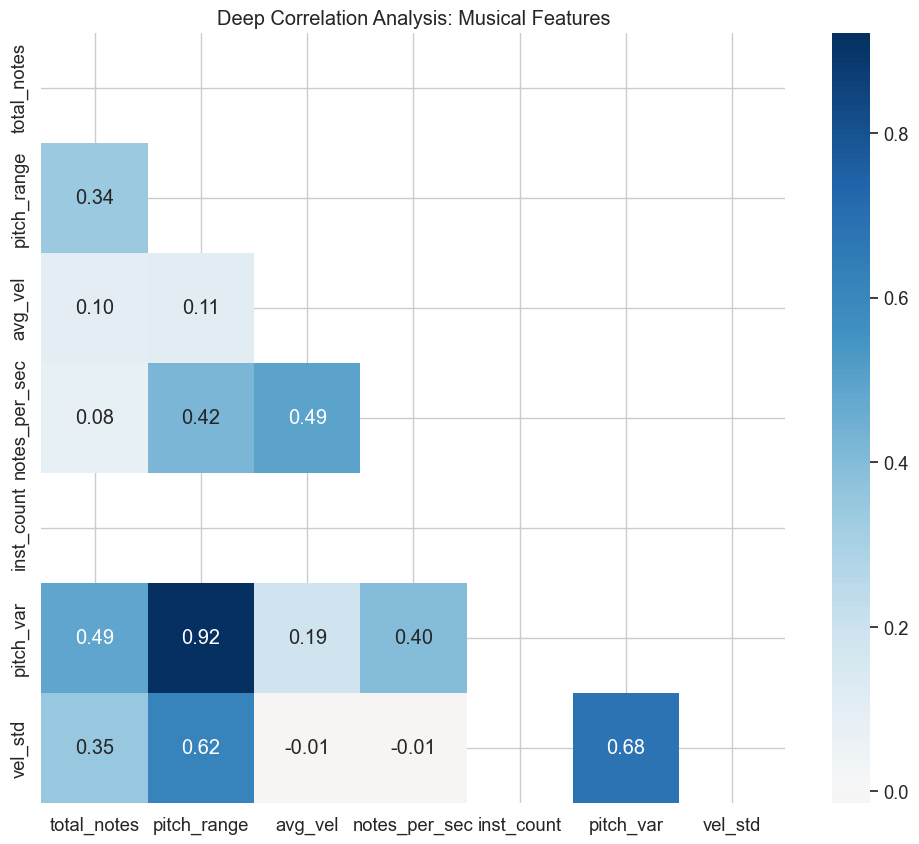

In [16]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pretty_midi

sns.set_context("notebook", font_scale=1.2)
plt.rcParams['figure.figsize'] = (14, 8)

df = pd.read_csv('data/maestro-v3.0.0/maestro-v3.0.0.csv')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.histplot(df['duration'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Piece Duration (Skewness Analysis)')
sns.boxplot(x='split', y='duration', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Duration Comparison by Dataset Split')
plt.show()

plt.figure(figsize=(12, 8))
top_composers = df['canonical_composer'].value_counts().head(12)
sns.barplot(x=top_composers.values, y=top_composers.index, palette='magma')
plt.title('Top 12 Composers: Productivity vs. Representation')
plt.xlabel('Number of Pieces')
plt.show()

def extract_detailed_features(row):
    try:
        pm = pretty_midi.PrettyMIDI(f"data/maestro-v3.0.0/{row['midi_filename']}")
        notes = [n for inst in pm.instruments for n in inst.notes]
        if not notes: return pd.Series([np.nan]*7)
        
        pitches = [n.pitch for n in notes]
        velocities = [n.velocity for n in notes]
        
        return pd.Series([
            len(notes), 
            np.max(pitches) - np.min(pitches), 
            np.mean(velocities), 
            len(notes) / row['duration'], 
            len(pm.instruments),
            len(set(pitches)),
            np.std(velocities) 
        ])
    except:
        return pd.Series([np.nan]*7)

sample_df = df.sample(150, random_state=42).copy()
cols = ['total_notes', 'pitch_range', 'avg_vel', 'notes_per_sec', 'inst_count', 'pitch_var', 'vel_std']
sample_df[cols] = sample_df.apply(extract_detailed_features, axis=1)
sample_df = sample_df.dropna()

sns.pairplot(sample_df[['duration', 'total_notes', 'notes_per_sec', 'pitch_var']], kind='reg', diag_kind='kde')
plt.suptitle('Multi-variate Relationships in Musical Complexity', y=1.02)
plt.show()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(sample_df[cols].corr(), dtype=bool))
sns.heatmap(sample_df[cols].corr(), mask=mask, annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title('Deep Correlation Analysis: Musical Features')
plt.show()


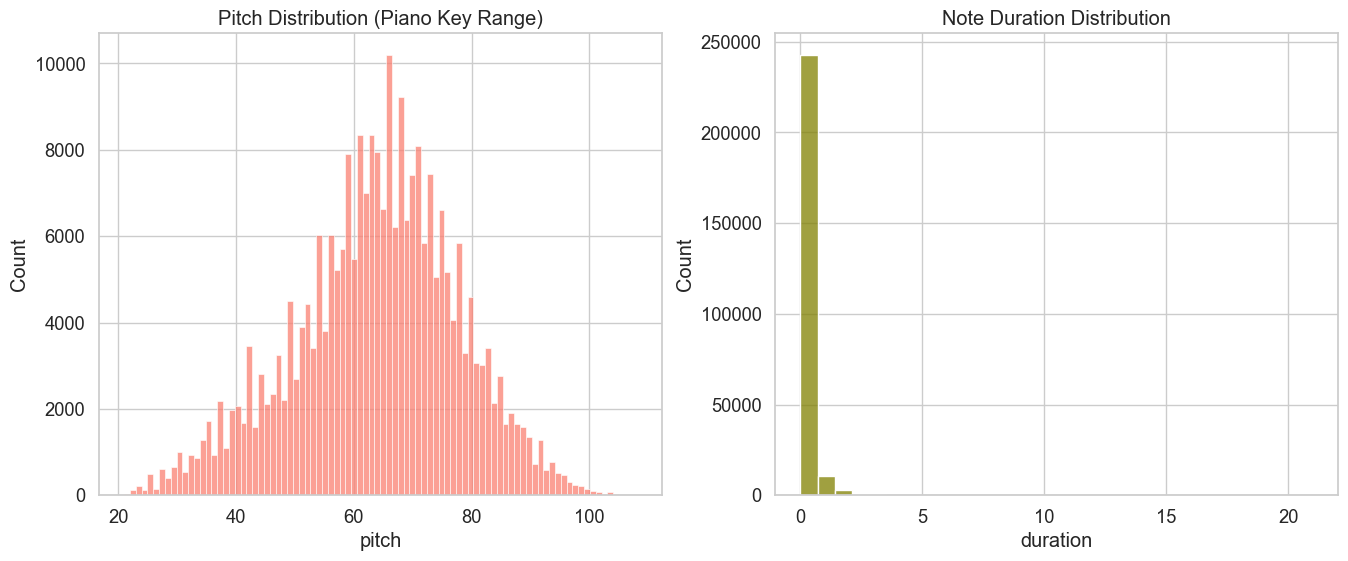

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pretty_midi
import os

midi_files = [os.path.join('data/maestro-v3.0.0', f) for f in df['midi_filename'].head(50)]

def get_musical_fingerprint(midi_path):
    try:
        pm = pretty_midi.PrettyMIDI(midi_path)
        notes = [n for inst in pm.instruments for n in inst.notes]
        if not notes: return None
        
        pitches = np.array([n.pitch for n in notes])
        intervals = np.diff(pitches)
        
        durations = np.array([n.end - n.start for n in notes])
        
        return pd.DataFrame({'pitch': pitches, 'duration': durations})
    except:
        return None

all_data = []
for f in midi_files:
    res = get_musical_fingerprint(f)
    if res is not None:
        all_data.append(res)

full_stats = pd.concat(all_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(full_stats['pitch'], bins=88, ax=axes[0], color='salmon')
axes[0].set_title('Pitch Distribution (Piano Key Range)')

sns.histplot(full_stats['duration'], bins=30, ax=axes[1], color='olive')
axes[1].set_title('Note Duration Distribution')
plt.show()

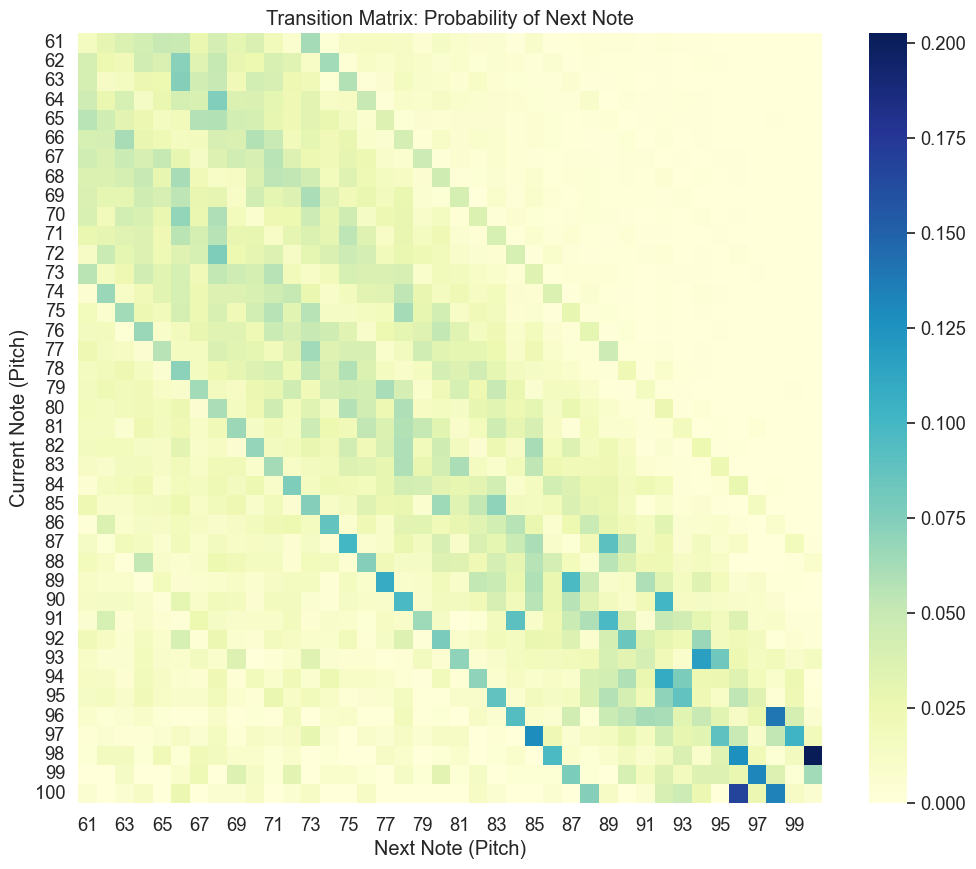

In [ ]:

def get_transition_matrix(full_stats):
    pitches = full_stats['pitch'].values
    transitions = pd.DataFrame({'current': pitches[:-1], 'next': pitches[1:]})
    matrix = pd.crosstab(transitions['current'], transitions['next'], normalize='index')
    return matrix

transition_matrix = get_transition_matrix(full_stats)

plt.figure(figsize=(12, 10))
sns.heatmap(transition_matrix.iloc[40:80, 40:80], cmap='YlGnBu')
plt.title('Transition Matrix: Probability of Next Note')
plt.xlabel('Next Note (Pitch)')
plt.ylabel('Current Note (Pitch)')
plt.show()

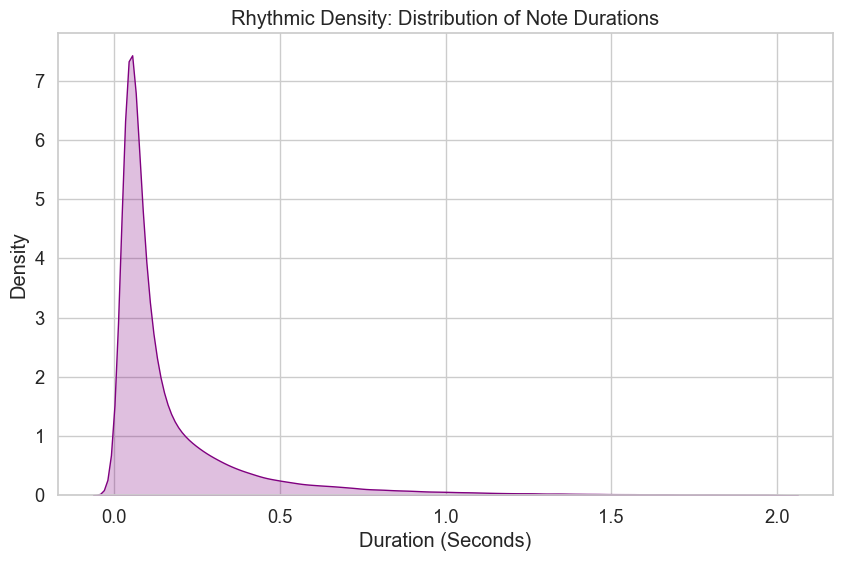

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(full_stats[full_stats['duration'] < 2]['duration'], fill=True, color='purple')
plt.title('Rhythmic Density: Distribution of Note Durations')
plt.xlabel('Duration (Seconds)')
plt.ylabel('Density')
plt.show()

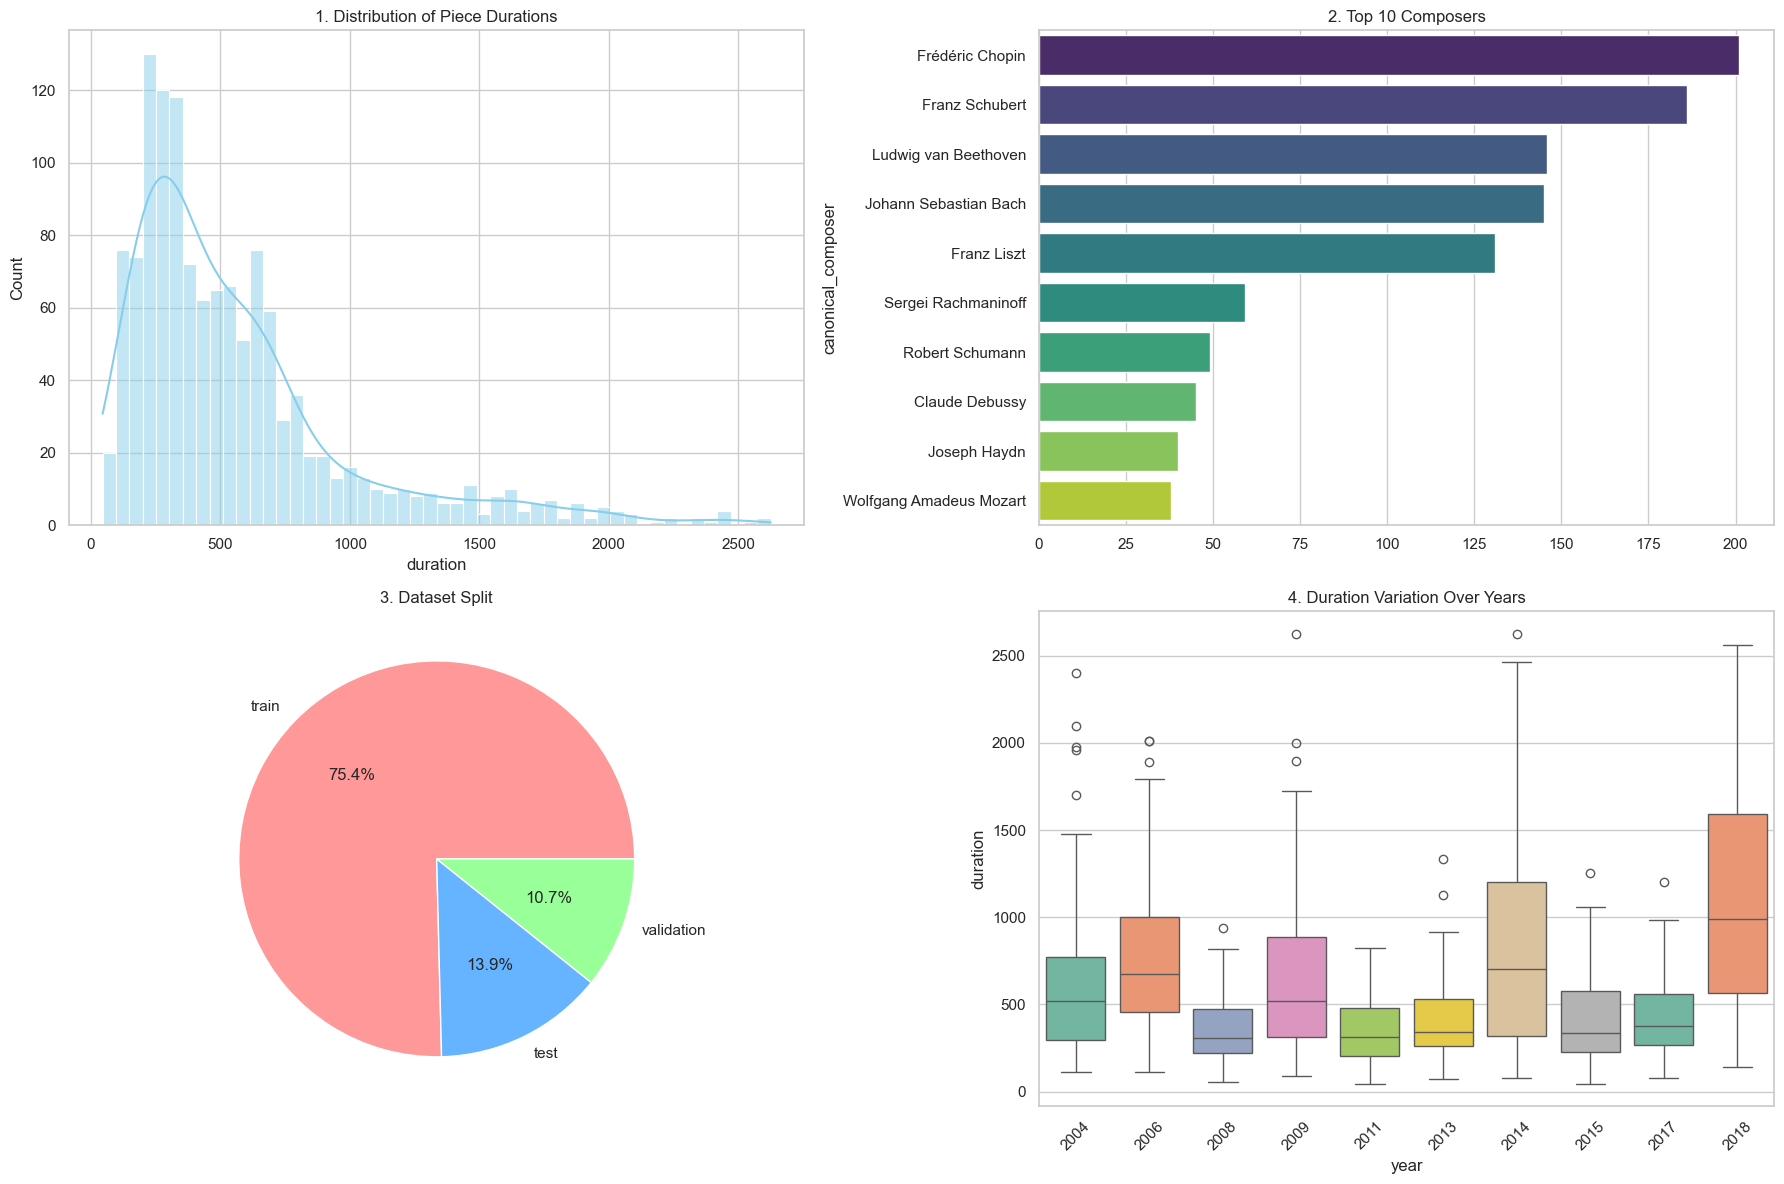

در حال پردازش داده‌های عمیق...


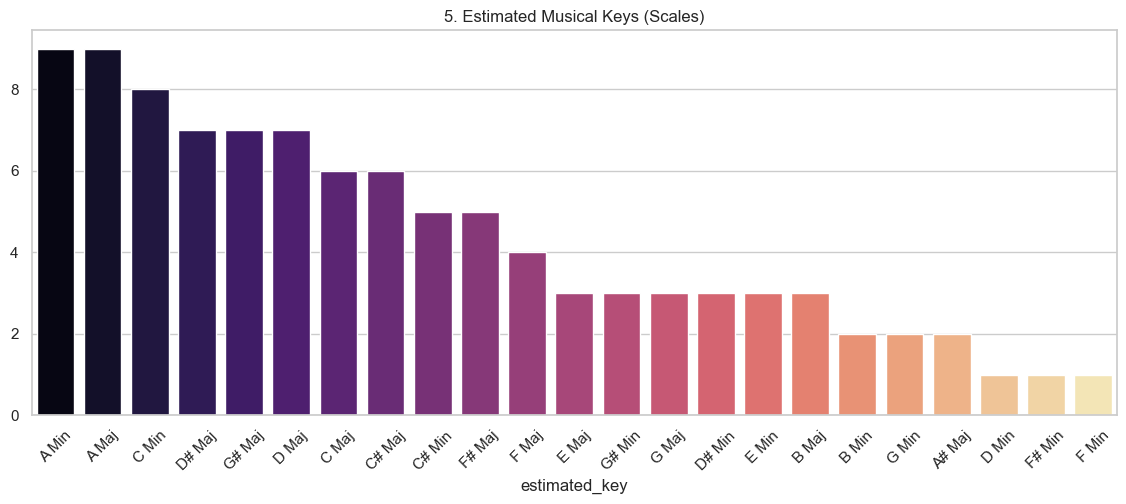

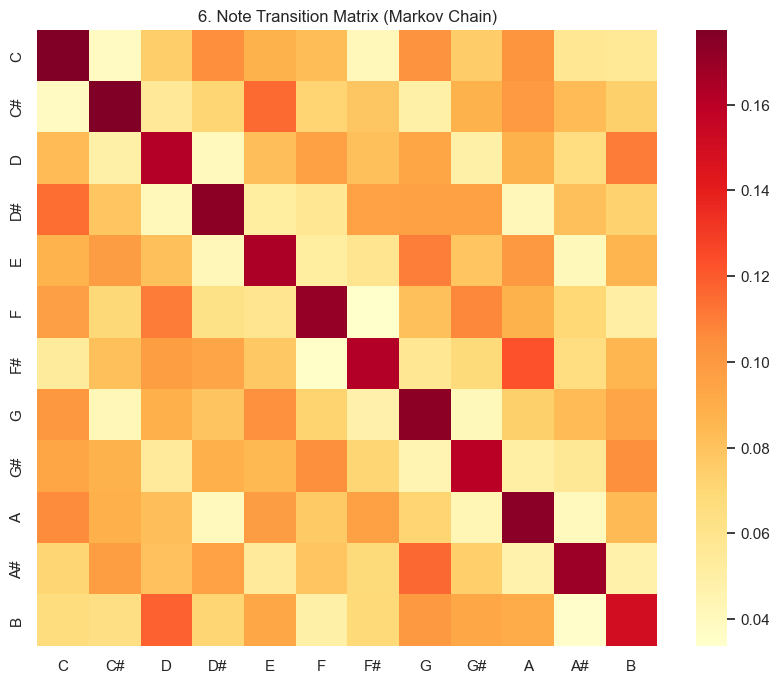

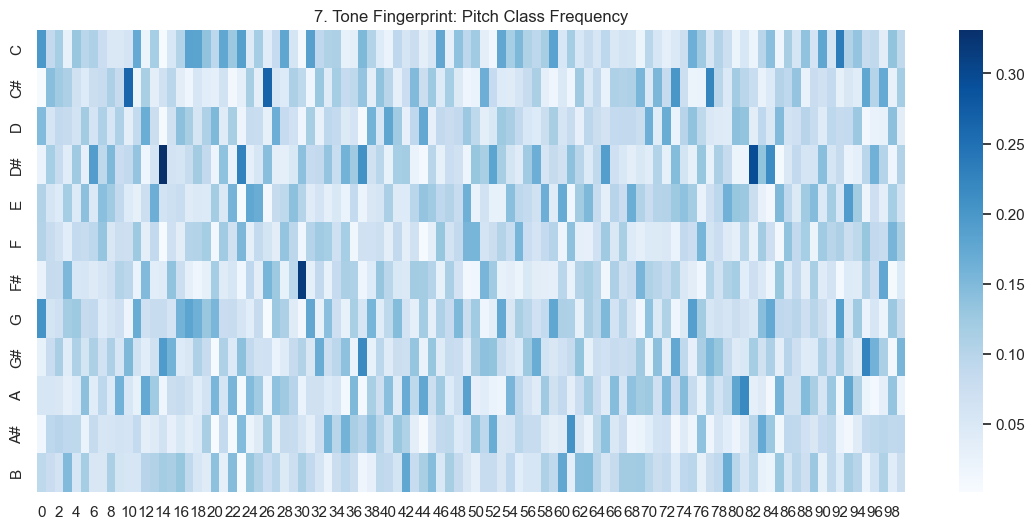

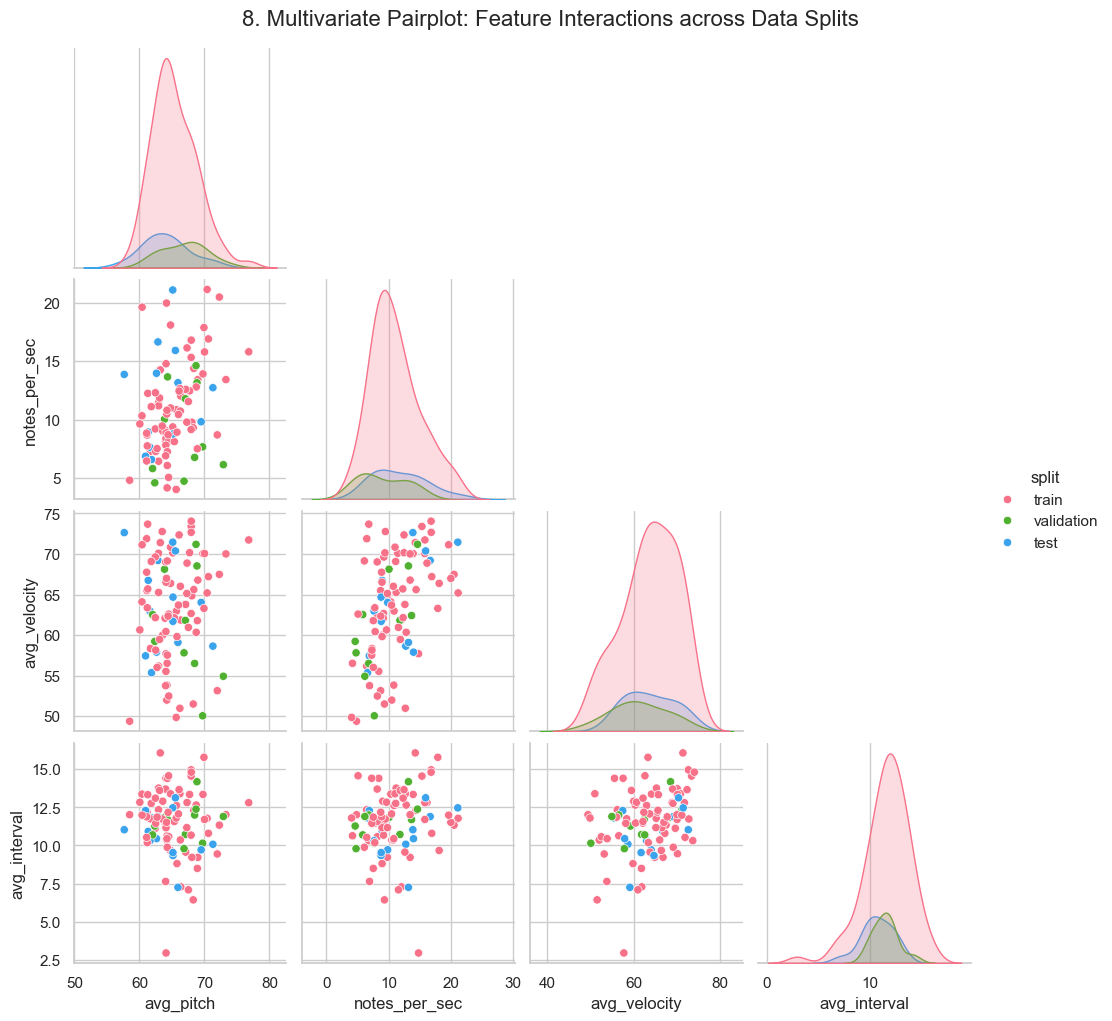

<Figure size 1200x1200 with 0 Axes>

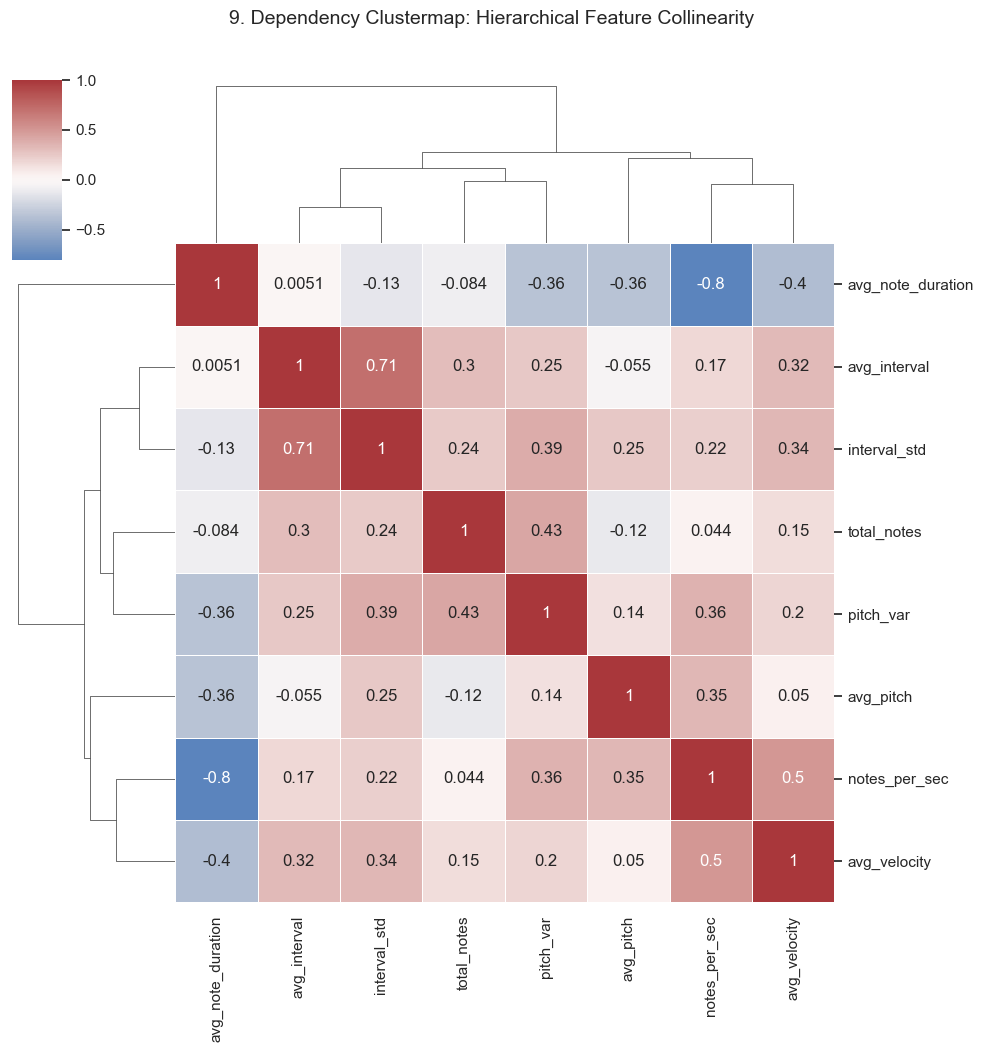

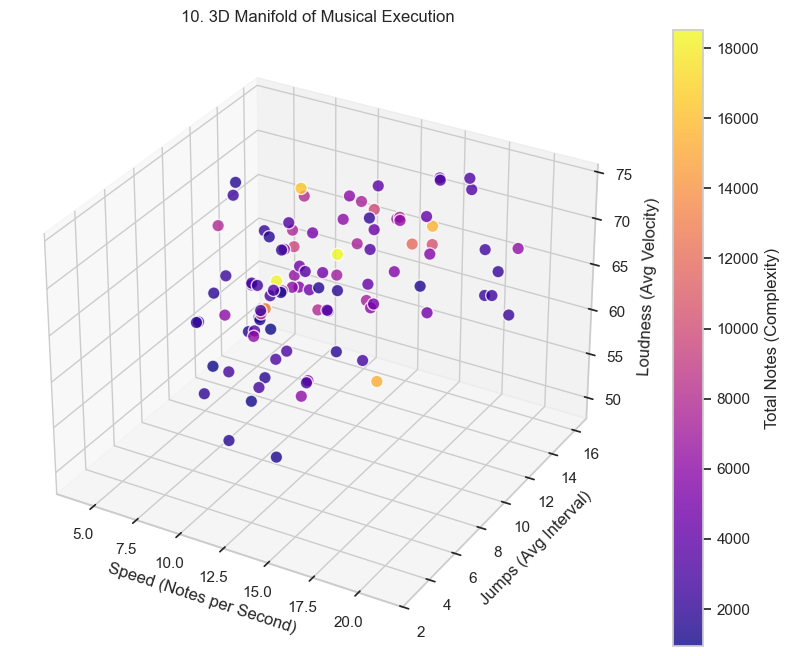

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pretty_midi

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

df = pd.read_csv('data/maestro-v3.0.0/maestro-v3.0.0.csv')


fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.histplot(df['duration'], bins=50, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('1. Distribution of Piece Durations')

top_composers = df['canonical_composer'].value_counts().head(10)
sns.barplot(x=top_composers.values, y=top_composers.index, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('2. Top 10 Composers')

split_counts = df['split'].value_counts()
axes[1, 0].pie(split_counts, labels=split_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
axes[1, 0].set_title('3. Dataset Split')

sns.boxplot(x='year', y='duration', data=df, ax=axes[1, 1], palette='Set2')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_title('4. Duration Variation Over Years')
plt.tight_layout()
plt.show()


maj_profile = [6.35, 2.23, 3.48, 2.33, 4.38, 4.09, 2.52, 5.19, 2.39, 3.66, 2.29, 2.88]
min_profile = [6.33, 2.68, 3.52, 5.38, 2.60, 3.53, 2.54, 4.75, 3.98, 2.69, 3.34, 3.17]
key_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

def estimate_key(pitch_classes):
    if sum(pitch_classes) == 0: return "Unknown"
    p = pitch_classes / sum(pitch_classes)
    best_corr, best_key = -1, "Unknown"
    for i in range(12):
        maj_c = np.corrcoef(p, np.roll(maj_profile, i))[0,1]
        min_c = np.corrcoef(p, np.roll(min_profile, i))[0,1]
        if maj_c > best_corr: best_corr, best_key = maj_c, key_names[i] + " Maj"
        if min_c > best_corr: best_corr, best_key = min_c, key_names[i] + " Min"
    return best_key

global_transitions = np.zeros((12, 12))

def extract_super_features(row):
    global global_transitions
    try:
        pm = pretty_midi.PrettyMIDI(f"data/maestro-v3.0.0/{row['midi_filename']}")
        notes = sorted([n for inst in pm.instruments for n in inst.notes], key=lambda x: x.start)
        if len(notes) < 2: return pd.Series([np.nan]*11)
        
        pitches = np.array([n.pitch for n in notes])
        velocities = np.array([n.velocity for n in notes])
        durations = np.array([n.end - n.start for n in notes])
        
        intervals = np.abs(np.diff(pitches)) 
        pitch_classes = pitches % 12
        pc_counts = np.bincount(pitch_classes, minlength=12)
        
        for i in range(len(pitch_classes)-1):
            global_transitions[pitch_classes[i], pitch_classes[i+1]] += 1
            
        estimated_key = estimate_key(pc_counts)
        
        return pd.Series([
            len(notes), np.mean(pitches), len(set(pitches)), len(notes) / row['duration'],
            pc_counts / len(notes), np.mean(velocities), np.mean(durations), 
            np.mean(intervals), np.std(intervals), estimated_key, row['split'] 
        ])
    except: return pd.Series([np.nan]*11)

print("در حال پردازش داده‌های عمیق...")
sample_df = df.sample(100, random_state=42).copy()
cols = ['total_notes', 'avg_pitch', 'pitch_var', 'notes_per_sec', 'pitch_dist', 
        'avg_velocity', 'avg_note_duration', 'avg_interval', 'interval_std', 'estimated_key', 'split']
sample_df[cols] = sample_df.apply(extract_super_features, axis=1)
sample_df = sample_df.dropna()

plt.figure(figsize=(14, 5))
key_counts = sample_df['estimated_key'].value_counts()
sns.barplot(x=key_counts.index, y=key_counts.values, palette='magma')
plt.title('5. Estimated Musical Keys (Scales)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 8))
transition_prob = global_transitions / global_transitions.sum(axis=1, keepdims=True)
sns.heatmap(transition_prob, annot=False, cmap='YlOrRd', xticklabels=key_names, yticklabels=key_names)
plt.title('6. Note Transition Matrix (Markov Chain)')
plt.show()

pitch_dist_matrix = np.stack(sample_df['pitch_dist'].values)
plt.figure(figsize=(14, 6))
sns.heatmap(pitch_dist_matrix.T, cmap='Blues', yticklabels=key_names)
plt.title('7. Tone Fingerprint: Pitch Class Frequency')
plt.show()

multi_cols = ['avg_pitch', 'notes_per_sec', 'avg_velocity', 'avg_interval', 'split']
sns.pairplot(sample_df[multi_cols], hue='split', palette='husl', diag_kind='kde', corner=True)
plt.suptitle('8. Multivariate Pairplot: Feature Interactions across Data Splits', y=1.02, fontsize=16)
plt.show()

corr_cols = ['total_notes', 'avg_pitch', 'pitch_var', 'notes_per_sec', 'avg_velocity', 'avg_note_duration', 'avg_interval', 'interval_std']
corr_matrix = sample_df[corr_cols].astype(float).corr()

plt.figure(figsize=(12, 12))
sns.clustermap(corr_matrix, annot=True, cmap='vlag', center=0, figsize=(10, 10),
               linewidths=0.5, cbar_pos=(0.02, 0.8, 0.05, 0.18))
plt.suptitle('9. Dependency Clustermap: Hierarchical Feature Collinearity', y=1.05, fontsize=14)
plt.show()

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

p = ax.scatter(sample_df['notes_per_sec'], sample_df['avg_interval'], sample_df['avg_velocity'], 
               c=sample_df['total_notes'], cmap='plasma', s=80, alpha=0.8, edgecolors='w')

ax.set_xlabel('Speed (Notes per Second)')
ax.set_ylabel('Jumps (Avg Interval)')
ax.set_zlabel('Loudness (Avg Velocity)')
ax.set_title('10. 3D Manifold of Musical Execution')
fig.colorbar(p, ax=ax, label='Total Notes (Complexity)')
plt.show()

Initializing Exploratory Data Analysis (EDA) Pipeline...


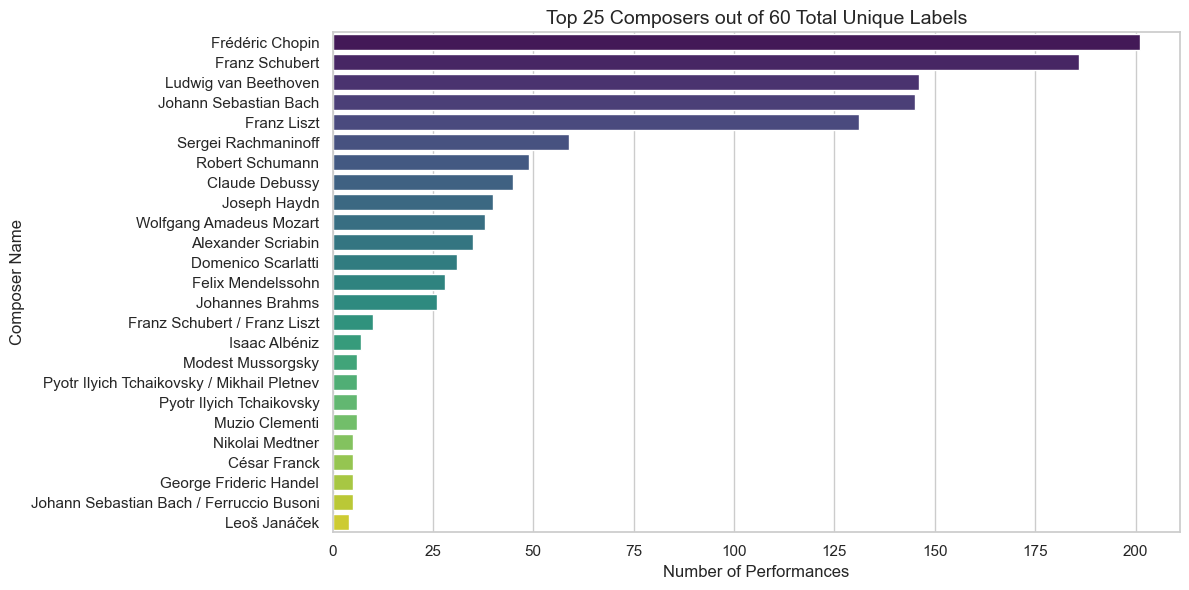

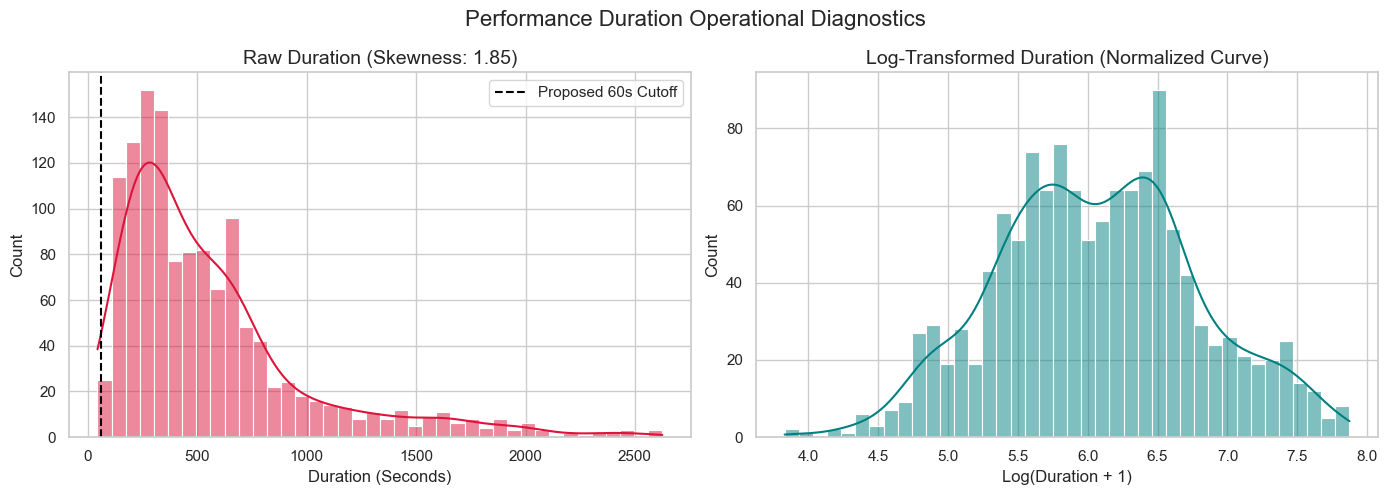

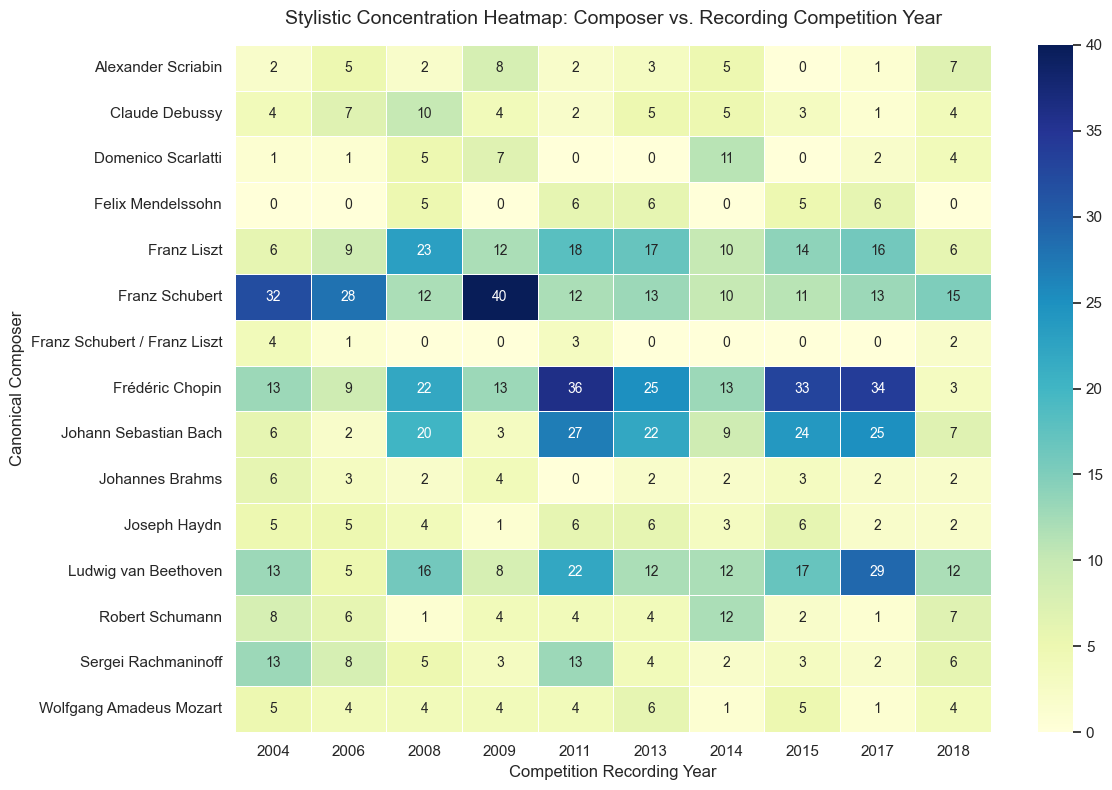

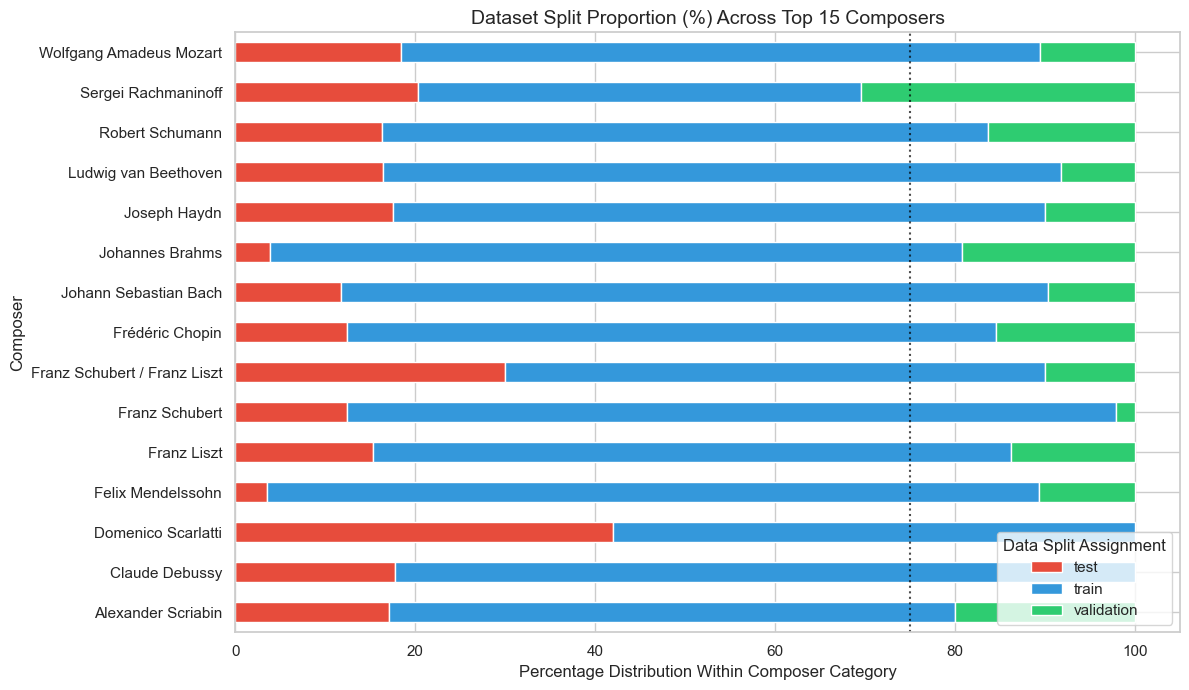


EDA DIAGNOSTICS COMPLETE!


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 12, 'axes.titlesize': 14})

print("Initializing Exploratory Data Analysis (EDA) Pipeline...")

csv_path = 'data/maestro-v3.0.0/maestro-v3.0.0.csv'
df = pd.read_csv(csv_path)

# -------------------------------------------------------------------------
# PLOT 1: COMPOSER DISTRIBUTION (The Long-Tail Problem)
# -------------------------------------------------------------------------
plt.figure(figsize=(12, 6))
composer_counts = df['canonical_composer'].value_counts()
sns.barplot(x=composer_counts.values[:25], y=composer_counts.index[:25], palette="viridis")
plt.title(f"Top 25 Composers out of {df['canonical_composer'].nunique()} Total Unique Labels")
plt.xlabel("Number of Performances")
plt.ylabel("Composer Name")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# PLOT 2: DURATION SKEWNESS ANALYSIS
# -------------------------------------------------------------------------
skew_val = df['duration'].skew()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['duration'], kde=True, ax=axes[0], color="crimson", bins=40)
axes[0].axvline(60, color='black', linestyle='--', linewidth=1.5, label='Proposed 60s Cutoff')
axes[0].set_title(f"Raw Duration (Skewness: {skew_val:.2f})")
axes[0].set_xlabel("Duration (Seconds)")
axes[0].legend()

sns.histplot(np.log1p(df['duration']), kde=True, ax=axes[1], color="teal", bins=40)
axes[1].set_title("Log-Transformed Duration (Normalized Curve)")
axes[1].set_xlabel("Log(Duration + 1)")

plt.suptitle("Performance Duration Operational Diagnostics", fontsize=16)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# PLOT 3: COMPOSER VS. RECORDING YEAR CROSS-TABULATION 
# -------------------------------------------------------------------------
# فیلتر کردن ۱۵ آهنگساز برتر برای خوانا شدن نقشه حرارتی
top_15_composers = df['canonical_composer'].value_counts().head(15).index
filtered_df = df[df['canonical_composer'].isin(top_15_composers)]

# ساخت جدول Cross-Tabulation
cross_tab = pd.crosstab(filtered_df['canonical_composer'], filtered_df['year'])

plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="YlGnBu", cbar=True, linewidths=0.5)
plt.title("Stylistic Concentration Heatmap: Composer vs. Recording Competition Year", pad=15)
plt.xlabel("Competition Recording Year")
plt.ylabel("Canonical Composer")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# PLOT 4: SPLIT DISTRIBUTION BALANCE (Train/Test/Val)
# -------------------------------------------------------------------------
split_cross = pd.crosstab(filtered_df['canonical_composer'], filtered_df['split'], normalize='index') * 100

split_cross.plot(kind='barh', stacked=True, figsize=(12, 7), color=['#e74c3c', '#3498db', '#2ecc71'])
plt.title("Dataset Split Proportion (%) Across Top 15 Composers")
plt.xlabel("Percentage Distribution Within Composer Category")
plt.ylabel("Composer")
plt.legend(title="Data Split Assignment", loc="lower right")
plt.axvline(75, color='black', linestyle=':', alpha=0.7) 
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("EDA DIAGNOSTICS COMPLETE!")
print("="*60)